In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os

sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

In [21]:
import segyio
with segyio.open('/Users/torka/Downloads/2025-09-15-09-53-58-gpr.sgy', strict=False, endian='little') as f:
    data = f.trace.raw[:]
    
#/Users/torka/Downloads/2025-09-15-09-53-58-gpr.sgy

RuntimeError: trace count inconsistent with file size, trace lengths possibly of non-uniform

In [ ]:
data_subset = data[:, :200]

In [14]:
L, S = rpca_pcp_ialm(
            data_subset,
            sparsity_factor= .5 / np.sqrt(max(data_subset.shape)), # 1 is a value. --> 0.5 or 0.75 are probably more appropriate in most cases!
            max_iter=100,
            verbose=False,
            tol=1e-9,
        )
        

In [6]:
data2 = data - np.einsum('ij->i',data)[:,None]/data.shape[1]

(100.0, 0.0)

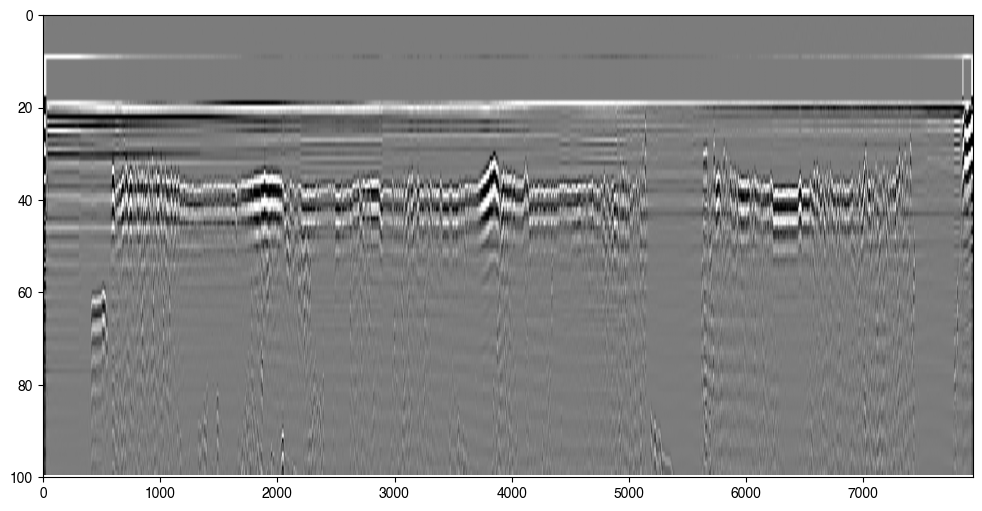

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(Quickboost(S.T), aspect='auto', cmap='gray')

ax.set_ylim(100, 0)